In [ ]:
from plots import *
run_all_plots()

In [ ]:
plot_monthly_avg_by_year()

In [ ]:
from plots import _load_pjm_data
df, year = _load_pjm_data(2023)
df.head()

In [ ]:
plot_acf(df['load_mw'], lags=np.arange(30*24, 30*24*12, 30*24))

In [ ]:
from plots import plot_temp_and_load_dual_axis, plot_temp_vs_load
for year in range(2016, 2026):
    plot_temp_vs_load(year)

In [ ]:
from plots import plot_holiday_window_average
plot_holiday_window_average()

In [3]:
from plots import _load_dataset_with_weather
df, year = _load_dataset_with_weather(2025)
year = int(year)
df.head()

Loading PJM data from hrl_load_metered_2025.csv...


Loaded 8759 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 8760 weather rows (Open-Meteo).


,load_mw,temp,dwpt,wspd
2025-01-01 00:00:00,3576.373,7.90,7.65,16.394829
2025-01-01 01:00:00,3435.604,7.05,6.80,12.549757
2025-01-01 02:00:00,3366.035,6.45,6.05,12.606426
2025-01-01 03:00:00,3309.721,6.20,5.80,14.120538
2025-01-01 04:00:00,3323.260,6.00,5.35,16.415567


In [4]:
import pandas as pd
christmas_start = pd.Timestamp(year=year, month=12, day=25) - pd.Timedelta(days=7)
christmas_end = pd.Timestamp(year=year, month=12, day=25) + pd.Timedelta(days=7)
christmas_data = df.loc[christmas_start:christmas_end]
christmas_data = christmas_data.resample('D').mean()

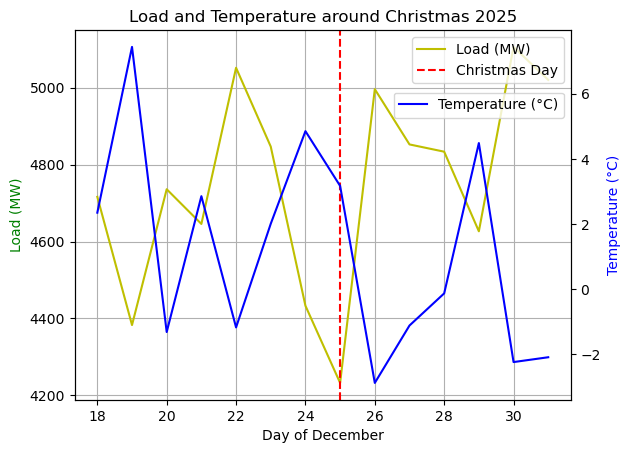

In [14]:
from matplotlib import pyplot as plt
fig, ax1 = plt.subplots()
ax2 = ax1.twinx()
ax1.plot(christmas_data.index.day, christmas_data['load_mw'], 'y-', label='Load (MW)')
ax2.plot(christmas_data.index.day, christmas_data['temp'], 'b-', label='Temperature (°C)')
ax1.set_xlabel('Day of December')
ax1.set_ylabel('Load (MW)', color='g')
ax2.set_ylabel('Temperature (°C)', color='b')
ax1.set_title(f'Load and Temperature around Christmas {year}')
ax2.legend(loc='upper right', bbox_to_anchor=(1, 0.85))
# add a vertical line at day 25
ax1.axvline(x=25, color='r', linestyle='--', label='Christmas Day')
ax1.legend(loc='upper right')
ax1.grid(True)


In [6]:
import pandas as pd
from load import create_dataset
from features import build_features
from models import NaiveMLR, rolling_forecast, evaluate_forecast, compute_metrics

LAT, LON = 39.96, -75.60

# ── Load real data: train on 2016-2022, test on 2023 ─────────────────────────
# Uses Open-Meteo ERA5 weather (cached after first fetch)
df = create_dataset("hrl_load_metered_combined.csv", "PE", LAT, LON)

df_train = df.loc["2016":"2022"]
df_test  = df.loc["2023"]

print(f"Train: {df_train.index[0].date()} → {df_train.index[-1].date()}  ({len(df_train):,} rows)")
print(f"Test : {df_test.index[0].date()}  → {df_test.index[-1].date()}  ({len(df_test):,} rows)")
print(f"NaNs in train temp: {df_train['temp'].isna().sum()}")
print(f"NaNs in test  temp: {df_test['temp'].isna().sum()}")

# ── 1. Feature matrix sanity check ───────────────────────────────────────────
X_train, y_train = build_features(df_train)
print(f"\nX_train shape : {X_train.shape}  (expect 281 cols)")
assert X_train.shape[1] == 281

# ── 2. Single fit → predict full test year ───────────────────────────────────
model = NaiveMLR()
preds = model.fit_predict(df_train, df_test)

metrics = compute_metrics(df_test["load_mw"], preds)
print("\n── Single-fit metrics (train 2016-22, test 2023) ──")
for k, v in metrics.items():
    print(f"  {k:6s}: {v:.3f}")

# ── 3. Rolling forecast on 2023 (retrain each day) ───────────────────────────
# Note: this retrains 365 times — takes a few minutes on real data
results = rolling_forecast(
    df,
    forecast_start=pd.Timestamp("2023-01-01"),
    forecast_end=pd.Timestamp("2023-12-31"),
)

print("\n── Rolling forecast metrics (2023) ──")
roll_metrics = evaluate_forecast(results)
for k, v in roll_metrics.items():
    print(f"  {k:6s}: {v:.3f}")

# ── 4. Breakdown by month ─────────────────────────────────────────────────────
from models import compute_metrics
monthly = compute_metrics(results["load_mw_actual"], results["load_mw_pred"], groupby="month")
print("\n── MAPE by month (rolling) ──")
months = ["Jan","Feb","Mar","Apr","May","Jun","Jul","Aug","Sep","Oct","Nov","Dec"]
for m, name in enumerate(months, start=1):
    if m in monthly:
        print(f"  {name}: {monthly[m]['MAPE']:.2f}%")


Loading PJM data from hrl_load_metered_combined.csv...


Loaded 87662 rows for Zone: PE
Fetching weather data via Open-Meteo (ERA5 Reanalysis)...
Fetched 87672 weather rows (Open-Meteo).
Train: 2016-01-01 → 2022-12-31  (61,368 rows)
Test : 2023-01-01  → 2023-12-31  (8,760 rows)
NaNs in train temp: 0
NaNs in test  temp: 0

X_train shape : (61368, 281)  (expect 281 cols)

── Single-fit metrics (train 2016-22, test 2023) ──
  MAE   : 192.360
  RMSE  : 286.305
  MAPE  : 4.366
  CVRMSE: 6.739


KeyboardInterrupt: 

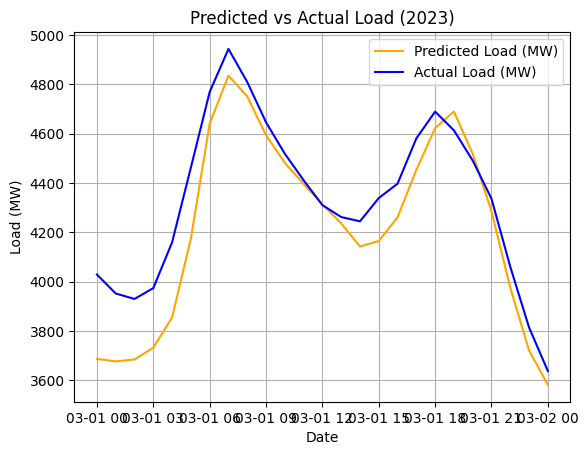

In [13]:
import matplotlib.pyplot as plt
start_time = pd.Timestamp("2023-03-01")
end_time = pd.Timestamp("2023-03-02")
plt.plot(preds[start_time:end_time], label="Predicted Load (MW)", color='orange')
plt.plot(df_test["load_mw"][start_time:end_time], label="Actual Load (MW)", color='blue')
plt.xlabel("Date")
plt.ylabel("Load (MW)")
plt.title("Predicted vs Actual Load (2023)")
plt.legend()
plt.grid(True)
plt.show()